In [69]:
#### ---------------------------------------------------------------------------------------------------------------------------
#### author: Ranjan Barman, date: July 8, 2025
#### predict individual BRCA Subtype Status using All HoverNet predicted NPIFs and also save the models for external validation
#### ----------------------------------------------------------------------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import argparse
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from collections import Counter, defaultdict
from sklearn.model_selection import cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, roc_auc_score, roc_curve, auc
import random
import joblib

# Parse command-line arguments
parser = argparse.ArgumentParser()
parser.add_argument("--percentile", type=int, required=True, help="Top X percentile for filtering tiles")
args = parser.parse_args()


_wpath_ = "/data/Lab_ruppin/Ranjan/HnE/"
os.chdir(_wpath_)

print(f"working directory = {_wpath_}\n")



working directory = /data/Lab_ruppin/Ranjan/HnE/



In [70]:
# Define dataset and file paths
dataset_name = "TCGA_BRCA_FFPE"
outcome_names = ["HER2_Status", "PR_Status", "ER_Status"]

# File paths
hovernet_NPIFs_with_BRCA_status_file = f"{dataset_name}/outputs/HoverNet/Subtypes/HoverNet_Original_NPIFs_Values_TCGA_BRCA_Mapped_BRCA_Status_Filtered_Tiles_Top{args.percentile}Q.csv"

# Output path to save results and plots
out_path = f"{dataset_name}/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top{args.percentile}Q_Binary_Subtypes/"
model_save_path = os.path.join(out_path, "saved_models/")
os.makedirs(model_save_path, exist_ok=True) # Creates directory if it doesn't exist already

# read files 
hovernet_NPIFs_with_BRCA_status_full = pd.read_csv(hovernet_NPIFs_with_BRCA_status_file)

# Remove trailing spaces from column names
hovernet_NPIFs_with_BRCA_status_full.columns = hovernet_NPIFs_with_BRCA_status_full.columns.str.strip()


# Rename the column
hovernet_NPIFs_with_BRCA_status_full.rename(columns={"sampleID": "sample_id"}, inplace=True)

# The number of samples used for TCGA BRCA subtype prediction 
TCGA_BRCA_Subtypes_556_file = f"{dataset_name}/outputs/HoverNet/Subtypes/outputs_biomarker_status_prediction_results_All_HoverNet_NPIFs/combined_class_predictions_all_features_for_subtypes.csv"

TCGA_BRCA_Subtypes_556 = pd.read_csv(TCGA_BRCA_Subtypes_556_file)

# Convert the first column ("sample") to a series
sample_list_556 = TCGA_BRCA_Subtypes_556['sample_id'].reset_index(drop=True)

# Filter sample based on `sample_list_556`
hovernet_NPIFs_with_BRCA_status_full = hovernet_NPIFs_with_BRCA_status_full[hovernet_NPIFs_with_BRCA_status_full['sample_id'].isin(sample_list_556)].copy()

# Convert the first column ("sample") to a series
patient_list = hovernet_NPIFs_with_BRCA_status_full['sample_id'].reset_index(drop=True)

# Filter to include only rows where outcome is "Positive" or "Negative"
data_filtered = hovernet_NPIFs_with_BRCA_status_full[
    hovernet_NPIFs_with_BRCA_status_full[outcome_names].isin(["Positive", "Negative"]).all(axis=1)
]

# Filter out the patient list
filtered_patient_list = data_filtered['sample_id'].reset_index(drop=True)

# Define features (before normalization)
X = data_filtered.iloc[:, 4:].copy()


hovernet_NPIFs_with_BRCA_status_full
filtered_patient_list
data_filtered
X

,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
0,9.083610,4.279521,2.904360,12.250657,0.688904,0.743519,3.839664,1.068454,0.643313,2.922380,0.145530,0.102340
1,10.750870,4.518914,3.215683,13.007940,0.653180,0.770368,4.950764,1.171824,0.748324,3.124821,0.153782,0.093280
2,11.115128,4.606071,3.274291,13.224772,0.659490,0.773457,4.633991,1.085960,0.706866,2.899793,0.146859,0.086521
3,12.963338,5.071167,3.436405,14.335088,0.690357,0.755218,7.114952,1.477987,0.931699,4.035264,0.145626,0.094786
4,11.696231,4.794285,3.296823,13.702952,0.675181,0.751392,6.340335,1.430814,0.858550,3.874959,0.150895,0.104859
...,...,...,...,...,...,...,...,...,...,...,...,...
710,12.469393,4.769945,3.442040,13.846007,0.643849,0.767721,6.768040,1.331533,0.991438,3.772418,0.160262,0.095114
711,12.708835,5.079825,3.372532,14.732758,0.697955,0.698507,7.681434,1.624340,1.003553,4.582990,0.150906,0.118566
712,14.269575,5.115578,3.686002,14.706263,0.648484,0.779478,6.709199,1.298417,0.964848,3.552653,0.154878,0.094389
713,12.896830,5.023687,3.431680,14.381161,0.679632,0.740519,6.918545,1.459972,0.965221,3.939845,0.155834,0.107518


In [71]:
# Initialize a DataFrame to store the combined results
combined_results_df = pd.DataFrame({'sample_id': filtered_patient_list.values})
combined_results_df.set_index('sample_id', inplace=True)

# Define hyperparameter grid for Logistic Regression with L2 penalty (Ridge)
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
}

# Define cross-validation parameters
n_folds = 5
seed = 20852
shuffle = True

# Define subtype names
subtype_names_3 = ['HER2_Positive', 'HR_Positive', 'TNBC_3']
subtype_names_4 = ['HR+', 'TNBC_4', 'TPBC', 'HER2+']
all_subtype_names = subtype_names_3 + subtype_names_4

# Step 1: Define true subtypes from HER2/ER/PR status
def define_true_subtypes(df):
    HER2 = df['HER2_Status'] == 'Positive'
    ER = df['ER_Status'] == 'Positive'
    PR = df['PR_Status'] == 'Positive'

    df['HER2_Positive'] = HER2.astype(int)
    df['HR_Positive'] = ((ER | PR) & ~HER2).astype(int)
    df['TNBC_3'] = (~HER2 & ~ER & ~PR).astype(int)

    df['HR+'] = (ER & ~HER2).astype(int)
    df['TNBC_4'] = (~ER & ~HER2).astype(int)
    df['TPBC'] = (ER & HER2).astype(int)
    df['HER2+'] = (~ER & HER2).astype(int)

    return df

# Apply subtype definition
data_filtered = define_true_subtypes(data_filtered)

# Step 2: Define NPIF features only (exclude all label-related columns)
columns_to_exclude = ['sample_id', 'HER2_Status', 'PR_Status', 'ER_Status',
                      'HER2_Positive', 'HR_Positive', 'TNBC_3', 'HR+',
                      'TNBC_4', 'TPBC', 'HER2+']
feature_columns = [col for col in data_filtered.columns if col not in columns_to_exclude]
X = data_filtered[feature_columns].copy()

data_filtered
# feature_columns
# X

,sample_id,HER2_Status,PR_Status,ER_Status,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,...,Std Perimeter,Std Eccentricity,Std Circularity,HER2_Positive,HR_Positive,TNBC_3,HR+,TNBC_4,TPBC,HER2+
0,TCGA-A1-A0SB,Negative,Negative,Positive,9.083610,4.279521,2.904360,12.250657,0.688904,0.743519,...,2.922380,0.145530,0.102340,0,1,0,1,0,0,0
1,TCGA-A1-A0SD,Negative,Positive,Positive,10.750870,4.518914,3.215683,13.007940,0.653180,0.770368,...,3.124821,0.153782,0.093280,0,1,0,1,0,0,0
2,TCGA-A1-A0SE,Negative,Positive,Positive,11.115128,4.606071,3.274291,13.224772,0.659490,0.773457,...,2.899793,0.146859,0.086521,0,1,0,1,0,0,0
3,TCGA-A1-A0SF,Negative,Positive,Positive,12.963338,5.071167,3.436405,14.335088,0.690357,0.755218,...,4.035264,0.145626,0.094786,0,1,0,1,0,0,0
4,TCGA-A1-A0SH,Negative,Positive,Negative,11.696231,4.794285,3.296823,13.702952,0.675181,0.751392,...,3.874959,0.150895,0.104859,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
710,TCGA-EW-A1PB,Negative,Negative,Negative,12.469393,4.769945,3.442040,13.846007,0.643849,0.767721,...,3.772418,0.160262,0.095114,0,0,1,0,1,0,0
711,TCGA-EW-A1PD,Positive,Positive,Positive,12.708835,5.079825,3.372532,14.732758,0.697955,0.698507,...,4.582990,0.150906,0.118566,1,0,0,0,0,1,0
712,TCGA-EW-A1PE,Negative,Positive,Positive,14.269575,5.115578,3.686002,14.706263,0.648484,0.779478,...,3.552653,0.154878,0.094389,0,1,0,1,0,0,0
713,TCGA-EW-A1PF,Negative,Positive,Positive,12.896830,5.023687,3.431680,14.381161,0.679632,0.740519,...,3.939845,0.155834,0.107518,0,1,0,1,0,0,0


In [72]:
# Initialize result storage
results = {}
mean_f1_scores = []

# Loop through each subtype
for subtype in all_subtype_names:
    print(f"\nProcessing subtype: {subtype}")
    
    y = data_filtered[subtype]
    y_encoded = y.copy()

    outer_results = []
    y_true_all_folds = []
    predictions = []
    f1_scores = []

    # Track coefficients for all features across folds
    all_features = X.columns.tolist()
    coeff_tracker = {feat: [] for feat in all_features}  # values per fold, zero if not selected

    outer_cv = StratifiedKFold(n_splits=n_folds, shuffle=shuffle, random_state=seed)
    fold_idx = 1

    for train_idx, test_idx in outer_cv.split(X, y_encoded):
        print(f"\nOuter Fold {fold_idx}/{n_folds}")
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_encoded.iloc[train_idx], y_encoded.iloc[test_idx]
        patient_test_ids = filtered_patient_list.iloc[test_idx]

        # Print class balance
        print("Train class dist:", y_train.value_counts().to_dict())
        print("Test class dist :", y_test.value_counts().to_dict())

        inner_cv = StratifiedKFold(n_splits=n_folds, shuffle=shuffle, random_state=seed)
        
        pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('classifier', LogisticRegression(penalty='l1', solver='saga',
                                              class_weight='balanced', max_iter=10000))
        ])
        
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1
        )
        
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"Best parameters: {best_params}")
        
        # Save model
        model_filename = os.path.join(model_save_path, f"{subtype}_model_fold_{fold_idx}.joblib")
        joblib.dump(best_model, model_filename)
        print(f"Saved model with scaler: {model_filename}")

        # Extract coefficients
        coef = best_model.named_steps['classifier'].coef_.flatten()
        for feat, c in zip(all_features, coef):
            coeff_tracker[feat].append(c)  # may be zero

        # Predict
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        predictions.append(y_pred_proba)
        y_true_all_folds.extend(y_test)

        # Save predictions to results DataFrame
        combined_results_df.loc[patient_test_ids.values, f'true_label_{subtype}'] = y_test.values
        combined_results_df.loc[patient_test_ids.values, f'predicted_probability_{subtype}'] = y_pred_proba

        # Evaluate
        f1 = f1_score(y_test, (y_pred_proba >= 0.5).astype(int))
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        f1_scores.append(f1)

        print(f"F1-score: {f1:.4f}")
        print(f"ROC AUC : {roc_auc:.4f}")

        outer_results.append({
            'fold': fold_idx,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'best_params': best_params
        })

        fold_idx += 1

    # Save results
    mean_f1_score = np.mean(f1_scores)
    print(f"Mean F1-score for {subtype}: {mean_f1_score:.4f}")

    results[subtype] = {
        'outer_results': outer_results,
        'mean_f1_score': mean_f1_score,
        'best_params': best_params
    }
    mean_f1_scores.append(mean_f1_score)

    # Compute average coefficient (fill missing folds with 0)
    for feat in coeff_tracker:
        if len(coeff_tracker[feat]) < n_folds:
            coeff_tracker[feat] += [0.0] * (n_folds - len(coeff_tracker[feat]))

    avg_coeffs = {feat: np.mean(coeff_tracker[feat]) for feat in coeff_tracker}
    non_zero_avg_coeffs = {feat: val for feat, val in avg_coeffs.items() if val != 0}

    # Save sorted list by average coefficient
    feature_df = pd.DataFrame.from_dict(non_zero_avg_coeffs, orient='index', columns=['avg_coefficient_across_folds'])
    feature_df.index.name = 'feature'
    feature_df = feature_df.sort_values(by='avg_coefficient_across_folds', ascending=False)

    output_file = os.path.join(out_path, f"{subtype}_nonzero_avg_coeff_features.csv")
    feature_df.to_csv(output_file)
    print(f"Saved non-zero features with average coefficients for {subtype} to: {output_file}")



Processing subtype: HER2_Positive

Outer Fold 1/5
Train class dist: {0: 378, 1: 66}
Test class dist : {0: 95, 1: 17}
Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2_Positive_model_fold_1.joblib
F1-score: 0.3571
ROC AUC : 0.7511

Outer Fold 2/5
Train class dist: {0: 378, 1: 67}
Test class dist : {0: 95, 1: 16}
Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2_Positive_model_fold_2.joblib
F1-score: 0.4074
ROC AUC : 0.7836

Outer Fold 3/5
Train class dist: {0: 378, 1: 67}
Test class dist : {0: 95, 1: 16}
Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_mo

/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/

Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2+_model_fold_1.joblib
F1-score: 0.1176
ROC AUC : 0.7514

Outer Fold 2/5
Train class dist: {0: 425, 1: 20}
Test class dist : {0: 106, 1: 5}


/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/

Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2+_model_fold_2.joblib
F1-score: 0.3704
ROC AUC : 0.9264

Outer Fold 3/5
Train class dist: {0: 425, 1: 20}
Test class dist : {0: 106, 1: 5}


...

Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2+_model_fold_3.joblib
F1-score: 0.2667
ROC AUC : 0.8566

Outer Fold 4/5
Train class dist: {0: 425, 1: 20}
Test class dist : {0: 106, 1: 5}


/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/

Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2+_model_fold_4.joblib
F1-score: 0.3030
ROC AUC : 0.9660

Outer Fold 5/5
Train class dist: {0: 425, 1: 20}
Test class dist : {0: 106, 1: 5}


/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/envs/py3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/Anaconda/

Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2+_model_fold_5.joblib
F1-score: 0.1765
ROC AUC : 0.7377
Mean F1-score for HER2+: 0.2468
Saved non-zero features with average coefficients for HER2+ to: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/HER2+_nonzero_avg_coeff_features.csv


In [73]:
# Save combined prediction outputs
combined_results_df.to_csv(os.path.join(out_path, 'combined_class_predictions_all_subtypes_binary.csv'), index=True)
combined_results_df

,true_label_HER2_Positive,predicted_probability_HER2_Positive,true_label_HR_Positive,predicted_probability_HR_Positive,true_label_TNBC_3,predicted_probability_TNBC_3,true_label_HR+,predicted_probability_HR+,true_label_TNBC_4,predicted_probability_TNBC_4,true_label_TPBC,predicted_probability_TPBC,true_label_HER2+,predicted_probability_HER2+
sample_id,,,,,,,,,,,,,,
TCGA-A1-A0SB,0.0,0.144764,1.0,0.838222,0.0,0.240933,1.0,0.879825,0.0,0.348360,0.0,0.297856,0.0,0.001418
TCGA-A1-A0SD,0.0,0.195424,1.0,0.777638,0.0,0.241335,1.0,0.787089,0.0,0.323228,0.0,0.190813,0.0,0.011170
TCGA-A1-A0SE,0.0,0.123601,1.0,0.881180,0.0,0.292380,1.0,0.889013,0.0,0.218142,0.0,0.241445,0.0,0.002257
TCGA-A1-A0SF,0.0,0.170830,1.0,0.522229,0.0,0.680149,1.0,0.532068,0.0,0.700425,0.0,0.358548,0.0,0.058807
TCGA-A1-A0SH,0.0,0.162269,1.0,0.782246,0.0,0.346525,0.0,0.728416,1.0,0.357456,0.0,0.234945,0.0,0.068729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-EW-A1PB,0.0,0.434037,0.0,0.367554,1.0,0.621093,0.0,0.425374,1.0,0.527783,0.0,0.538828,0.0,0.275860
TCGA-EW-A1PD,1.0,0.080163,0.0,0.639232,0.0,0.839212,0.0,0.520710,0.0,0.640301,1.0,0.225497,0.0,0.002833
TCGA-EW-A1PE,0.0,0.483328,1.0,0.603410,0.0,0.365582,1.0,0.667506,0.0,0.249080,0.0,0.376527,0.0,0.032960


In [74]:
# Mapping for 3-subtype ROC plotting
subtypes_3 = {
    'HER2_Positive': ('true_label_HER2_Positive', 'predicted_probability_HER2_Positive'),
    'HR_Positive': ('true_label_HR_Positive', 'predicted_probability_HR_Positive'),
    'TNBC_3': ('true_label_TNBC_3', 'predicted_probability_TNBC_3')
}

# Mapping for 4-subtype ROC plotting
subtypes_4 = {
    'HR+': ('true_label_HR+', 'predicted_probability_HR+'),
    'TNBC_4': ('true_label_TNBC_4', 'predicted_probability_TNBC_4'),
    'TPBC': ('true_label_TPBC', 'predicted_probability_TPBC'),
    'HER2+': ('true_label_HER2+', 'predicted_probability_HER2+')
}


In [75]:
colors = {
    'HER2_Positive': 'darkorange',
    'HR_Positive': 'blue',
    'TNBC_3': 'green',
    'HR+': 'blue',
    'TNBC_4': 'green',
    'TPBC': 'tomato',
    'HER2+': 'darkorange'
}
def plot_combined_roc_curves(df, subtypes, title, filename):
    plt.figure(figsize=(10, 8))
    total_samples = len(df)

    for subtype, (true_label_col, pred_prob_col) in subtypes.items():
        if subtype in ['TNBC_3', 'TNBC_4']:
            if 'TNBC' in colors:  # Avoid duplicated legend for TNBC
                continue
            label = 'TNBC'
        elif subtype == 'HER2_Positive':
            label = 'HER2+'
        elif subtype == 'HR_Positive':
            label = 'HR+'
        else:
            label = subtype

        # Filter valid entries
        valid_indices = (~df[true_label_col].isna()) & (~df[pred_prob_col].isna())
        true_labels = df[true_label_col][valid_indices]
        predicted_probs = df[pred_prob_col][valid_indices]

        # Compute ROC and AUC
        fpr, tpr, _ = roc_curve(true_labels, predicted_probs)
        roc_auc = auc(fpr, tpr)

        # Plot
        plt.plot(fpr, tpr, color=colors[subtype], lw=2,
                 label=f'{label} (AUC = {roc_auc:.2f}, n = {true_labels.sum():.0f})')

    # Reference diagonal
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=18)
    plt.ylabel('True Positive Rate', fontsize=18)
    plt.title(title, fontsize=18)
    plt.legend(loc="lower right", fontsize=18)
    plt.grid(True)

    # Save and show
    plt.savefig(os.path.join(out_path, filename), bbox_inches='tight')
    plt.show()


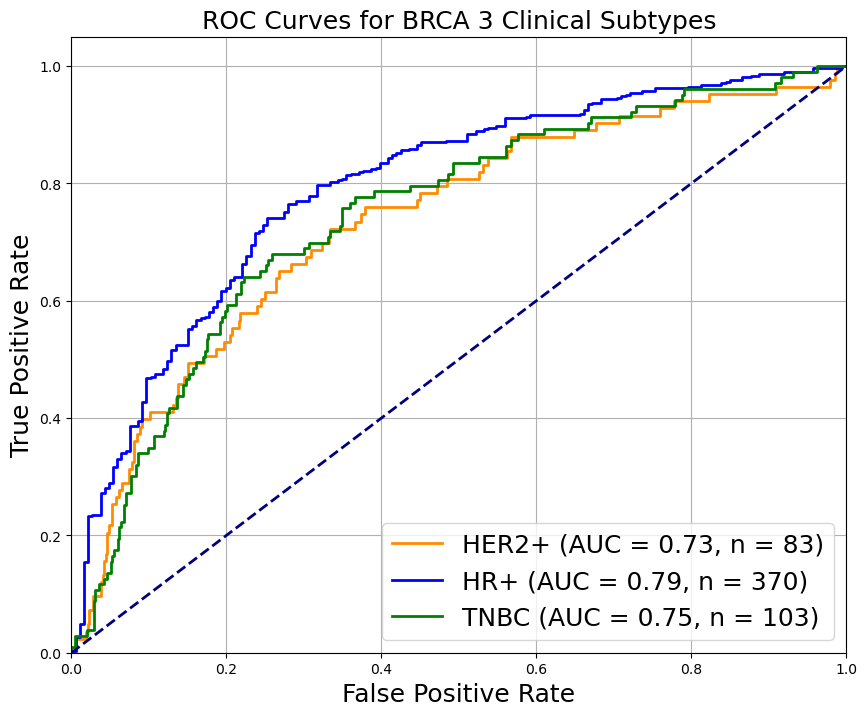

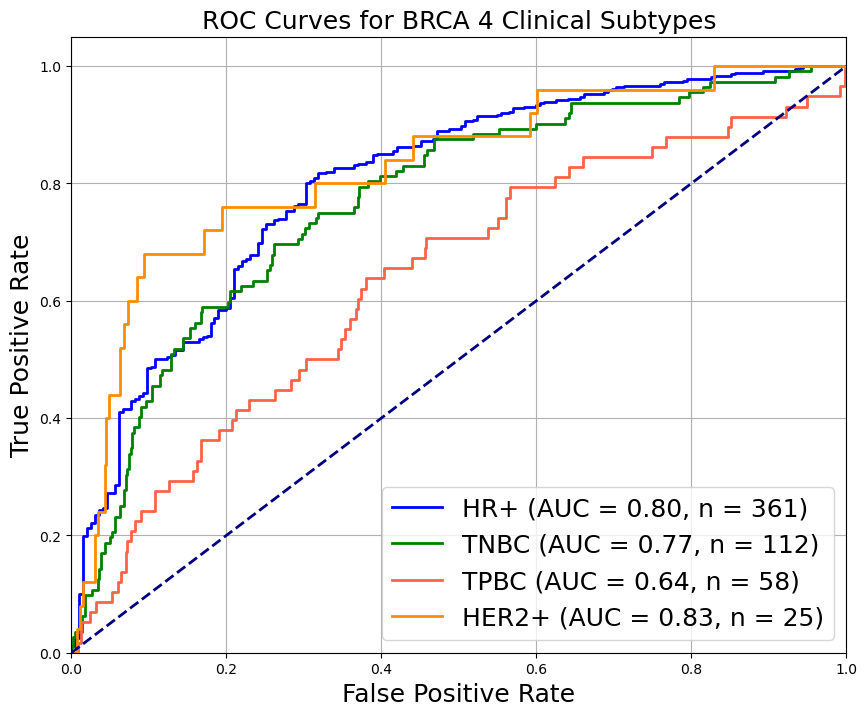

In [76]:
plot_combined_roc_curves(
    combined_results_df,
    subtypes_3,
    'ROC Curves for BRCA 3 Clinical Subtypes',
    'roc_3_subtypes.png'
)

plot_combined_roc_curves(
    combined_results_df,
    subtypes_4,
    'ROC Curves for BRCA 4 Clinical Subtypes',
    'roc_4_subtypes.png'
)



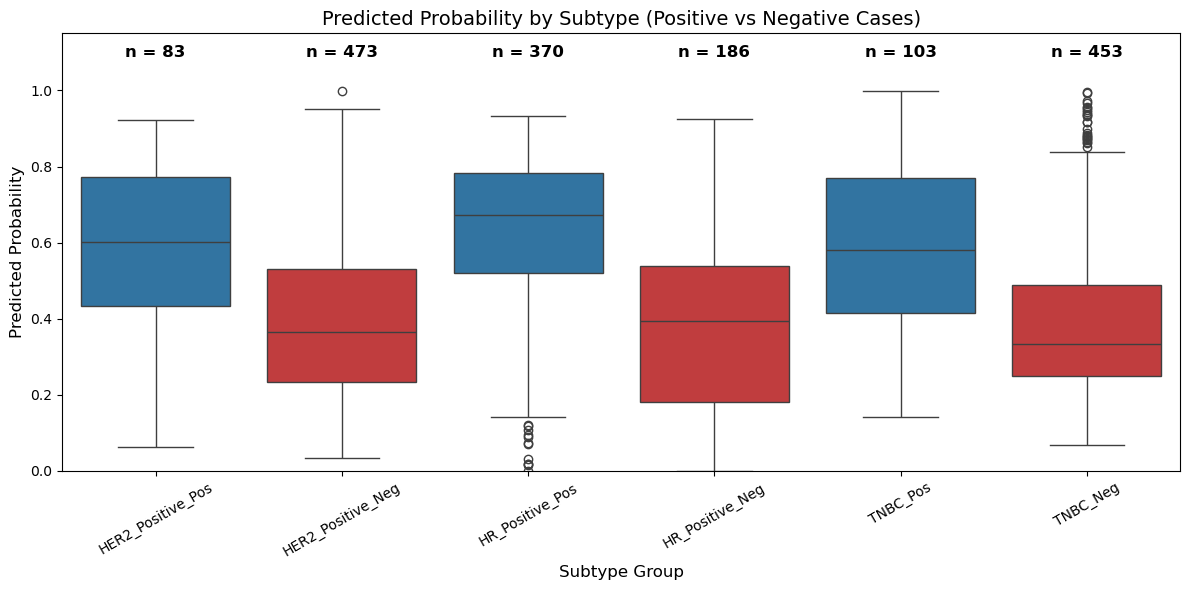

In [77]:
# Prepare positive and negative subsets using true label columns
HER2_pos = combined_results_df[combined_results_df['true_label_HER2_Positive'] == 1]
HER2_neg = combined_results_df[combined_results_df['true_label_HER2_Positive'] == 0]

HR_pos = combined_results_df[combined_results_df['true_label_HR_Positive'] == 1]
HR_neg = combined_results_df[combined_results_df['true_label_HR_Positive'] == 0]

TNBC_pos = combined_results_df[combined_results_df['true_label_TNBC_3'] == 1]
TNBC_neg = combined_results_df[combined_results_df['true_label_TNBC_3'] == 0]

# Construct a DataFrame for boxplot visualization
plot_df = pd.DataFrame({
    'Subtype_Label': ['HER2_Positive_Pos'] * len(HER2_pos) +
                     ['HER2_Positive_Neg'] * len(HER2_neg) +
                     ['HR_Positive_Pos'] * len(HR_pos) +
                     ['HR_Positive_Neg'] * len(HR_neg) +
                     ['TNBC_Pos'] * len(TNBC_pos) +
                     ['TNBC_Neg'] * len(TNBC_neg),
    'Predicted_Probability': pd.concat([
        HER2_pos['predicted_probability_HER2_Positive'],
        HER2_neg['predicted_probability_HER2_Positive'],
        HR_pos['predicted_probability_HR_Positive'],
        HR_neg['predicted_probability_HR_Positive'],
        TNBC_pos['predicted_probability_TNBC_3'],
        TNBC_neg['predicted_probability_TNBC_3']
    ], axis=0)
})

# Define color palette for positive/negative cases
palette = {
    'HER2_Positive_Pos': '#1f77b4',
    'HER2_Positive_Neg': '#d62728',
    'HR_Positive_Pos': '#1f77b4',
    'HR_Positive_Neg': '#d62728',
    'TNBC_Pos': '#1f77b4',
    'TNBC_Neg': '#d62728'
}

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=plot_df,
    x='Subtype_Label',
    y='Predicted_Probability',
    hue='Subtype_Label',
    palette=palette,
    legend=False
)

# Annotate sample sizes above each box
group_counts = plot_df['Subtype_Label'].value_counts()
for tick, label in enumerate(ax.get_xticklabels()):
    subtype = label.get_text()
    count = group_counts[subtype]
    ax.text(tick, 1.08, f'n = {count}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='black')

# Final formatting
ax.set_ylim(0, 1.15)
plt.title("Predicted Probability by Subtype (Positive vs Negative Cases)", fontsize=14)
plt.xlabel("Subtype Group", fontsize=12)
plt.ylabel("Predicted Probability", fontsize=12)
plt.xticks(rotation=30, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


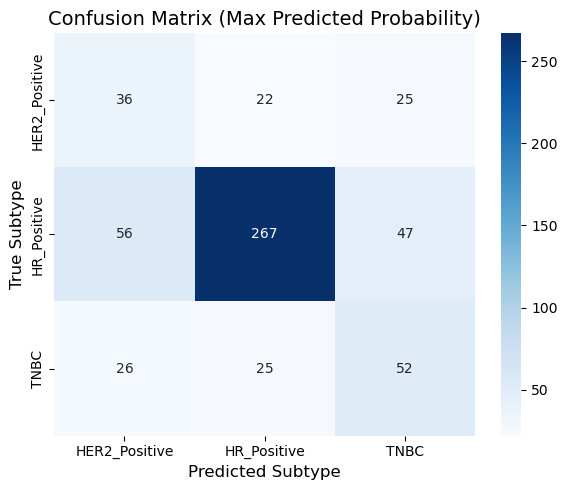

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Define subtype labels
subtypes = ['HER2_Positive', 'HR_Positive', 'TNBC']

# Step 1: Define true labels using true_label_<subtype> columns
def get_true_subtype(row):
    if row['true_label_HER2_Positive'] == 1:
        return 'HER2_Positive'
    elif row['true_label_HR_Positive'] == 1:
        return 'HR_Positive'
    elif row['true_label_TNBC_3'] == 1:
        return 'TNBC'
    else:
        return 'Unknown'

# Step 2: Assign predicted subtype using max of predicted probabilities
def get_predicted_subtype(row):
    probs = {
        'HER2_Positive': row['predicted_probability_HER2_Positive'],
        'HR_Positive': row['predicted_probability_HR_Positive'],
        'TNBC': row['predicted_probability_TNBC_3']
    }
    return max(probs, key=probs.get)

# Apply true and predicted subtype logic
combined_results_df['true_subtype'] = combined_results_df.apply(get_true_subtype, axis=1)
combined_results_df['predicted_subtype'] = combined_results_df.apply(get_predicted_subtype, axis=1)

# Step 3: Filter valid rows (exclude ambiguous/unknown cases)
valid_df = combined_results_df[combined_results_df['true_subtype'] != 'Unknown']

# Step 4: Compute confusion matrix
cm = confusion_matrix(valid_df['true_subtype'], valid_df['predicted_subtype'], labels=subtypes)

# Step 5: Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=subtypes, yticklabels=subtypes)
plt.xlabel("Predicted Subtype", fontsize=12)
plt.ylabel("True Subtype", fontsize=12)
plt.title("Confusion Matrix (Max Predicted Probability)", fontsize=14)
plt.tight_layout()
plt.show()


In [79]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define subtype order
subtypes = ['HER2_Positive', 'HR_Positive', 'TNBC']

# Step 1: Extract true and predicted labels
y_true = valid_df['true_subtype']
y_pred = valid_df['predicted_subtype']

# Step 2: Compute overall accuracy
overall_accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {overall_accuracy:.4f}")

# Step 3: Generate classification report for defined subtypes
report = classification_report(y_true, y_pred, labels=subtypes, output_dict=True)

# Step 4: Compute per-class metrics using confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=subtypes)
balanced_accuracies = []
specificities = []
recalls = []

for i, label in enumerate(subtypes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # same as recall
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    balanced_accuracy = (sensitivity + specificity) / 2

    recalls.append(round(sensitivity, 4))
    specificities.append(round(specificity, 4))
    balanced_accuracies.append(round(balanced_accuracy, 4))

# Step 5: Create metrics dataframe in required column order
metrics_df = pd.DataFrame({
    'balanced_accuracy': balanced_accuracies,
    'sensitivity (recall)': recalls,
    'specificity': specificities,
    'precision': [report[label]['precision'] for label in subtypes],
    'f1-score': [report[label]['f1-score'] for label in subtypes],
    'support': [report[label]['support'] for label in subtypes],
}, index=subtypes)

# Step 6: Round for display
metrics_df = metrics_df.round(4)

# Step 7: Compute and print mean balanced accuracy
mean_balanced_accuracy = round(sum(balanced_accuracies) / len(balanced_accuracies), 4)
print(f"\nMean Balanced Accuracy: {mean_balanced_accuracy:.4f}")

# Step 8: Print final metrics
print("\nPer-Class Performance Metrics:")
metrics_df



Overall Accuracy: 0.6385

Mean Balanced Accuracy: 0.6792

Per-Class Performance Metrics:


,balanced_accuracy,sensitivity (recall),specificity,precision,f1-score,support
HER2_Positive,0.6302,0.4337,0.8266,0.3051,0.3582,83.0
HR_Positive,0.7345,0.7216,0.7473,0.8503,0.7807,370.0
TNBC,0.6730,0.5049,0.8411,0.4194,0.4581,103.0
